# MobileNet：面向移动端的图像分类（教学案例）

**知识点简述**：MobileNet 是一种面向移动端/嵌入式设备的轻量级卷积神经网络，通过**深度可分离卷积**显著减少参数量与计算量，在保证较好精度的同时大幅降低模型大小与推理延迟。

**学习意义**：在资源受限场景中（手机、IoT、边缘设备），我们需要在“准确率—速度—模型大小”之间做权衡。MobileNet 是理解这种权衡的典型案例，也是从“重模型”到“轻量模型”的重要过渡。

本案例将使用 `TensorFlow/Keras` 直接调用预训练 `MobileNetV2`，在 CIFAR-10 数据集上完成迁移学习，并给出训练过程、评估结果与预测示例。

## 数据集说明

我们使用 **CIFAR-10**（10 类彩色图片，32×32）作为教学数据集。

**当前数据集位置**：D:\xiangmu\20-mobilenet\data  
请确保已将 `cifar-10-batches-py` 解压在该目录下。

本案例将**直接从本地读取**数据，不再自动下载。

In [35]:
import os
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 数据集位置（已提前下载/解压）
DATA_DIR = r"D:\xiangmu\20-mobilenet\data"
os.makedirs(DATA_DIR, exist_ok=True)

# 结果可复现
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow 版本:", tf.__version__)
print("可用 GPU:", tf.config.list_physical_devices("GPU"))
print("数据集目录:", DATA_DIR)

TensorFlow 版本: 2.20.0
可用 GPU: []
数据集目录: D:\xiangmu\20-mobilenet\data


## 1. 读取数据并查看基本信息

我们先加载 CIFAR-10，并查看数据形状与类别名称。

In [36]:
def _load_batch(file_path: str):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    data = batch[b"data"]
    labels = batch[b"labels"]
    return data, labels


def load_cifar10_from_local(data_dir: str):
    base_dir = os.path.join(data_dir, "cifar-10-batches-py")
    if not os.path.isdir(base_dir):
        raise FileNotFoundError(
            "未找到 cifar-10-batches-py，请确认已解压到: " + base_dir
        )

    x_list, y_list = [], []
    for i in range(1, 6):
        data, labels = _load_batch(os.path.join(base_dir, f"data_batch_{i}"))
        x_list.append(data)
        y_list.extend(labels)

    x_train = np.concatenate(x_list, axis=0)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.array(y_list).reshape(-1, 1)

    x_test, y_test = _load_batch(os.path.join(base_dir, "test_batch"))
    x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    return (x_train, y_train), (x_test, y_test)


(x_train, y_train), (x_test, y_test) = load_cifar10_from_local(DATA_DIR)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("训练集:", x_train.shape, y_train.shape)
print("测试集:", x_test.shape, y_test.shape)
print("类别示例:", class_names)

训练集: (50000, 32, 32, 3) (50000, 1)
测试集: (10000, 32, 32, 3) (10000, 1)
类别示例: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. 可视化部分样本

观察数据分布与图像质量，有助于理解任务难度。

D:\Temp\ipykernel_20772\103500665.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


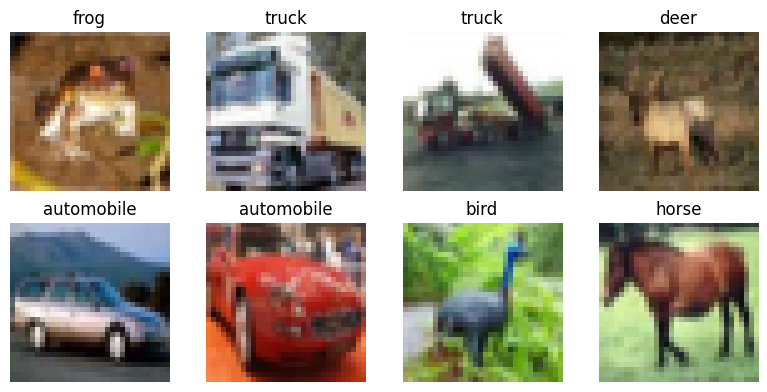

In [37]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. 数据预处理与输入管道

MobileNetV2 预训练模型要求输入大小至少为 32×32，我们将 CIFAR-10 图片**缩放到 96×96**，并使用 `preprocess_input` 做归一化。

In [38]:
IMG_SIZE = 96
BATCH_SIZE = 64

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# 训练/验证划分
val_size = 5000
x_val, y_val = x_train[:val_size], y_train[:val_size]
x_train_sub, y_train_sub = x_train[val_size:], y_train[val_size:]

print("训练子集:", x_train_sub.shape, y_train_sub.shape)
print("验证集:", x_val.shape, y_val.shape)

@tf.function
def preprocess_fn(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess(image)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train_sub, y_train_sub))
    .shuffle(10000, seed=SEED)
    .map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 查看一个 batch 的形状
for images, labels in train_ds.take(1):
    print("Batch 图像:", images.shape, "Batch 标签:", labels.shape)

训练子集: (45000, 32, 32, 3) (45000, 1)
验证集: (5000, 32, 32, 3) (5000, 1)
Batch 图像: (64, 96, 96, 3) Batch 标签: (64, 1)


## 4. 构建 MobileNetV2 迁移学习模型

我们优先**从本地加载预训练权重**，避免联网下载失败：

- 期望权重文件名：`mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5`
- 放置路径：D:\xiangmu\20-mobilenet\data

若本地不存在该文件，将退化为 `weights=None`（从头训练主干）。

In [39]:
weights_name = "mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5"
local_weights = os.path.join(DATA_DIR, weights_name)
use_local_weights = os.path.exists(local_weights)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights=None  # 先用 None，若本地有权重再手动加载
)

if use_local_weights:
    base_model.load_weights(local_weights)
    print("已加载本地预训练权重:", local_weights)
else:
    print("未找到本地权重，将从头训练主干网络")

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

未找到本地权重，将从头训练主干网络


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. 训练模型

先进行少量 epoch 的训练，以便快速展示流程与中间结果。

In [40]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10  # 最后一行参数后无逗号，避免多余分隔符
)

print("训练完成。最后一轮训练准确率：", history.history["accuracy"][-1])
print("最后一轮验证准确率：", history.history["val_accuracy"][-1])

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3027
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3029
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.0985 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.0975 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.0985 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.1005 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3029
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.0987 - loss: 2

## 5.1 训练曲线可视化

展示训练/验证的损失与准确率曲线，便于观察收敛情况。

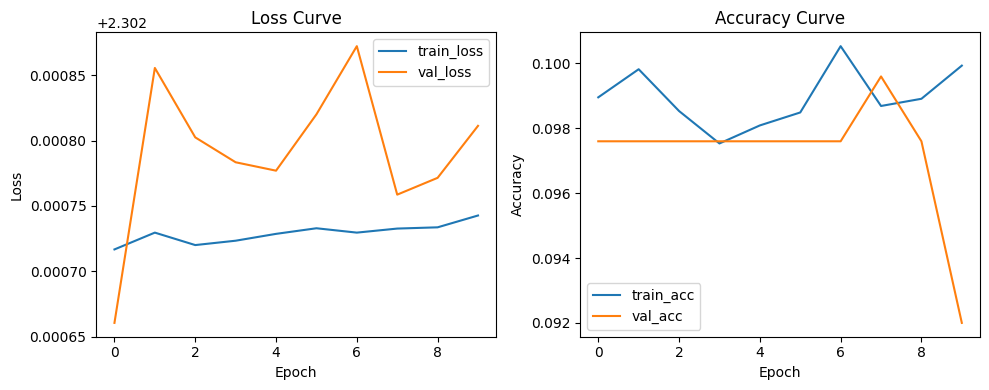

In [41]:
history_dict = history.history

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_dict.get("loss", []), label="train_loss")
plt.plot(history_dict.get("val_loss", []), label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict.get("accuracy", []), label="train_acc")
plt.plot(history_dict.get("val_accuracy", []), label="val_acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 6. 评估模型

在测试集上评估分类准确率。

In [42]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"测试集准确率: {test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.1000 - loss: 2.3026
测试集准确率: 0.1000


## 7. 预测示例与可视化

随机挑选几张测试图像，展示预测结果与真实标签。

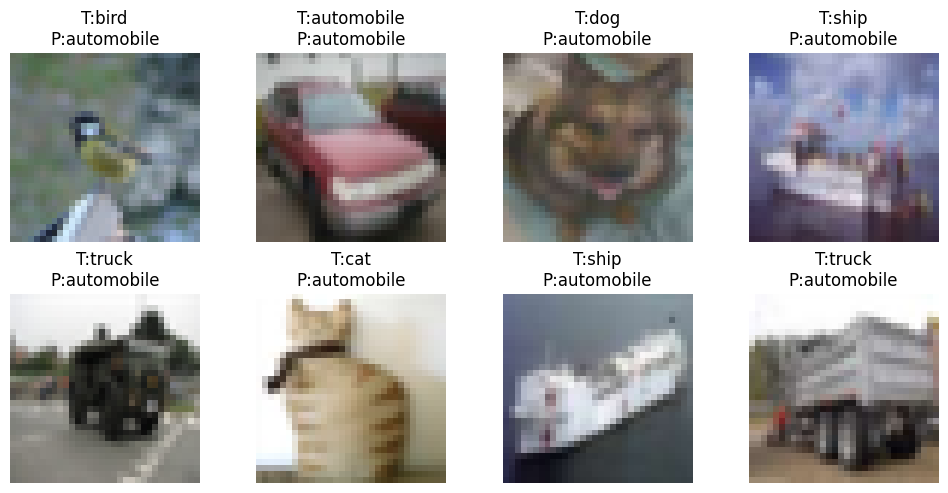

In [43]:
# 随机挑选 8 张图片
idx = np.random.choice(len(x_test), size=8, replace=False)
images = x_test[idx]
labels = y_test[idx].flatten()

# 预处理并预测
images_resized = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
images_resized = preprocess(tf.cast(images_resized, tf.float32))
probs = model.predict(images_resized, verbose=0)
preds = np.argmax(probs, axis=1)

# 可视化
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    title = f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}"
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. 小结

我们完成了从数据读取、预处理、迁移学习建模、训练评估到预测展示的完整流程。通过 MobileNetV2，模型在保持较少参数量的同时获得了可用的分类性能，适合移动端部署场景。

## 9. 拓展与思考（含解答思路）

1. **如果将输入尺寸从 96×96 提高到 160×160，会发生什么？**  
   - 思路：输入更大通常带来更高精度，但计算量也会显著增加；可通过对比训练速度与准确率验证。

2. **如何在不明显降低精度的前提下进一步压缩模型？**  
   - 思路：尝试更小的宽度系数（MobileNetV2 的 `alpha`）、量化（post-training quantization）、剪枝等方法。

3. **为什么迁移学习能在小数据集上表现更好？**  
   - 思路：预训练模型已经学到通用视觉特征（边缘、纹理、形状），在小数据集上只需学习高层语义映射。

4. **若要部署到手机端，除了模型大小还需考虑哪些指标？**  
   - 思路：推理延迟、内存峰值、功耗，以及框架兼容性（如 TFLite）等。

5. **如何进一步提升性能？**  
   - 思路：解冻部分顶层进行微调（fine-tuning），使用数据增强，或更长训练周期与学习率调度。